# Go/No-Go Analysis

Este notebook analiza los resultados de la tarea Go/No-Go, una tarea de **control inhibitorio**.

## La Tarea
- **Go trials (Azul)**: El participante debe presionar la barra espaciadora
- **No-Go trials (Naranja)**: El participante NO debe presionar nada

## Métricas Principales
- **HR (Hit Rate)**: Proporción de aciertos en Go trials
- **FA (False Alarm)**: Proporción de falsas alarmas en No-Go trials
- **c**: Criterio de respuesta (estandarizado)
- **sensibilidad**: Capacidad de discriminación
- **eficiencia**: Acc(Go) - Acc(NoGo)


In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.loader import get_latest_gonogo_analysis, load_gonogo_analysis

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)


## 1. Cargar Datos

### Opción A: Cargar análisis existente (rápido)


In [2]:
# Cargar el análisis más reciente
result = get_latest_gonogo_analysis()

if result is not None:
    df, config_info = result
    print(f"Análisis cargado: {config_info.get('timestamp', 'N/A')}")
    print(f"Total sujetos: {len(df)}")
    print(f"  - Datapruebas: {len(df[df['origin'] == 'datapruebas'])}")
    print(f"  - Neuropruebas: {len(df[df['origin'] == 'neuropruebas'])}")
else:
    print("No se encontró análisis previo. Ejecuta la celda de Opción B.")


Análisis cargado: 2026-01-12_12-05-14
Total sujetos: 310
  - Datapruebas: 67
  - Neuropruebas: 243


### Opción B: Ejecutar análisis fresco (más lento)


In [3]:
# Descomentar para ejecutar análisis desde cero
# df, save_path = load_gonogo_analysis(save_results=True)
# print(f"Análisis completado. Guardado en: {save_path}")


## 2. Exploración de Datos


In [4]:
df.head(10)


,subject_id,media_rt,mediana_rt,accuracy,FA,HR,eficiencia,recorded_at,user_agent,device,browser,platform,n_go_trials,n_nogo_trials,c,HR_FA_sin_estandarizar,sensibilidad,origin
0,b658934b-1bbc-4897-a989-1827a61cfb03,286.37,262.25,0.63,0.56,0.71,0.27,NaN,NaN,NaN,NaN,NaN,105,45,-0.53,-0.64,-3.13,datapruebas
1,f5a98897-4f58-4bc8-931e-4a2063542291,374.00,375.50,0.87,0.16,0.88,0.03,NaN,NaN,NaN,NaN,NaN,105,45,0.13,-0.52,1.36,datapruebas
2,4ba9507b-7579-4553-bc1c-d65cdb304613,329.86,328.90,0.70,0.40,0.74,0.14,NaN,NaN,NaN,NaN,NaN,105,45,-0.09,-0.57,-1.69,datapruebas
3,7d540a4e-9e01-472d-93aa-37f42cbfc693,332.04,331.90,0.93,0.09,0.94,0.03,NaN,NaN,NaN,NaN,NaN,105,45,0.11,-0.52,2.43,datapruebas
4,a31fee9a-3e68-4347-925c-cdc898edfc3f,351.02,362.00,0.68,0.62,0.81,0.43,NaN,NaN,NaN,NaN,NaN,105,45,-1.21,-0.72,-2.63,datapruebas
5,3f45b93b-b0e2-427d-a081-40a19722db2f,343.08,343.75,0.90,0.16,0.92,0.08,NaN,NaN,NaN,NaN,NaN,105,45,-0.05,-0.54,1.74,datapruebas
6,39675e5b-4e50-4bb2-9764-e434c64b3b8a,304.93,294.20,0.89,0.22,0.94,0.17,NaN,NaN,NaN,NaN,NaN,105,45,-0.36,-0.58,1.49,datapruebas
7,19e5c3c3-6564-4280-8154-225ac8b69d83,308.21,289.30,0.73,0.36,0.77,0.13,NaN,NaN,NaN,NaN,NaN,105,45,-0.08,-0.56,-1.11,datapruebas
8,c0c7054a-aab8-4efd-9e13-73fb99463ea7,361.54,364.40,0.76,0.27,0.77,0.04,NaN,NaN,NaN,NaN,NaN,105,45,0.25,-0.52,-0.46,datapruebas
9,d82cfda0-f10e-4619-bff0-d78b387387f5,384.85,387.50,0.75,0.27,0.76,0.03,NaN,NaN,NaN,NaN,NaN,105,45,0.29,-0.52,-0.55,datapruebas


In [5]:
df.describe()


,media_rt,mediana_rt,accuracy,FA,HR,eficiencia,n_go_trials,n_nogo_trials,c,HR_FA_sin_estandarizar,sensibilidad
count,310.000000,310.000000,310.000000,310.000000,310.000000,310.000000,310.0,310.0,310.000000,310.000000,310.000000
mean,333.145290,329.967710,0.793387,0.272194,0.821194,0.093935,105.0,45.0,0.000097,-0.546968,0.000226
std,26.382097,32.694334,0.095364,0.137724,0.107225,0.149632,0.0,0.0,0.604100,0.075173,1.593976
min,231.530000,206.450000,0.610000,0.000000,0.550000,-0.340000,105.0,45.0,-2.160000,-0.830000,-3.230000
25%,317.810000,310.025000,0.710000,0.180000,0.740000,0.010000,105.0,45.0,-0.310000,-0.580000,-1.267500
50%,333.530000,330.775000,0.790000,0.240000,0.830000,0.075000,105.0,45.0,0.045000,-0.540000,-0.140000
75%,350.115000,353.175000,0.870000,0.360000,0.910000,0.160000,105.0,45.0,0.360000,-0.502500,1.250000
max,401.120000,431.150000,1.000000,0.780000,1.000000,0.660000,105.0,45.0,1.850000,-0.330000,3.640000


## 3. HR vs FA (Signal Detection Theory)


/tmp/ipykernel_493278/3682782761.py:19: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df[['HR', 'FA']].hist(ax=ax2, bins=20, alpha=0.7)


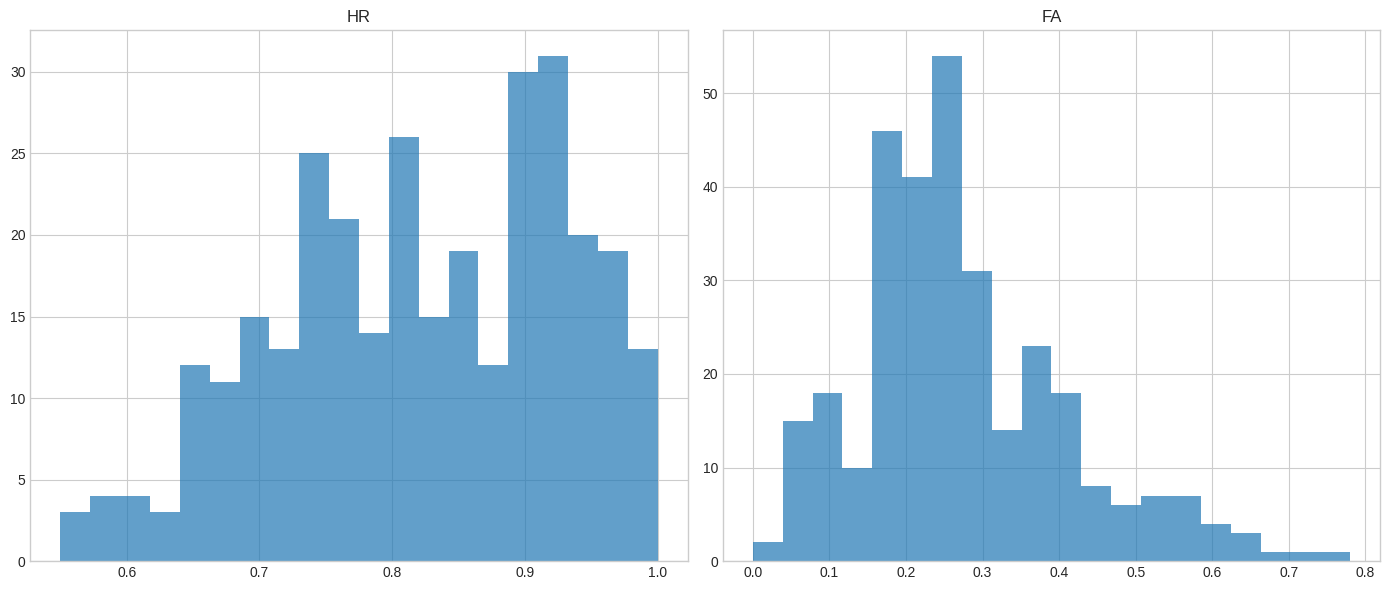

Correlación HR-FA: r = -0.270


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC Space
ax1 = axes[0]
for origin in ['datapruebas', 'neuropruebas']:
    subset = df[df['origin'] == origin]
    ax1.scatter(subset['FA'], subset['HR'], alpha=0.6, label=origin, s=50)
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Chance')
ax1.scatter([0], [1], color='green', s=200, marker='*', label='Ideal', zorder=5)
ax1.set_xlabel('False Alarm Rate (FA)')
ax1.set_ylabel('Hit Rate (HR)')
ax1.set_title('ROC Space: HR vs FA')
ax1.legend()
ax1.set_xlim(-0.05, 1.05)
ax1.set_ylim(-0.05, 1.05)

# Distribuciones
ax2 = axes[1]
df[['HR', 'FA']].hist(ax=ax2, bins=20, alpha=0.7)
ax2.set_title('Distribución de HR y FA')

plt.tight_layout()
plt.show()

print(f"Correlación HR-FA: r = {df['HR'].corr(df['FA']):.3f}")


## 4. Criterio (c) y Sensibilidad


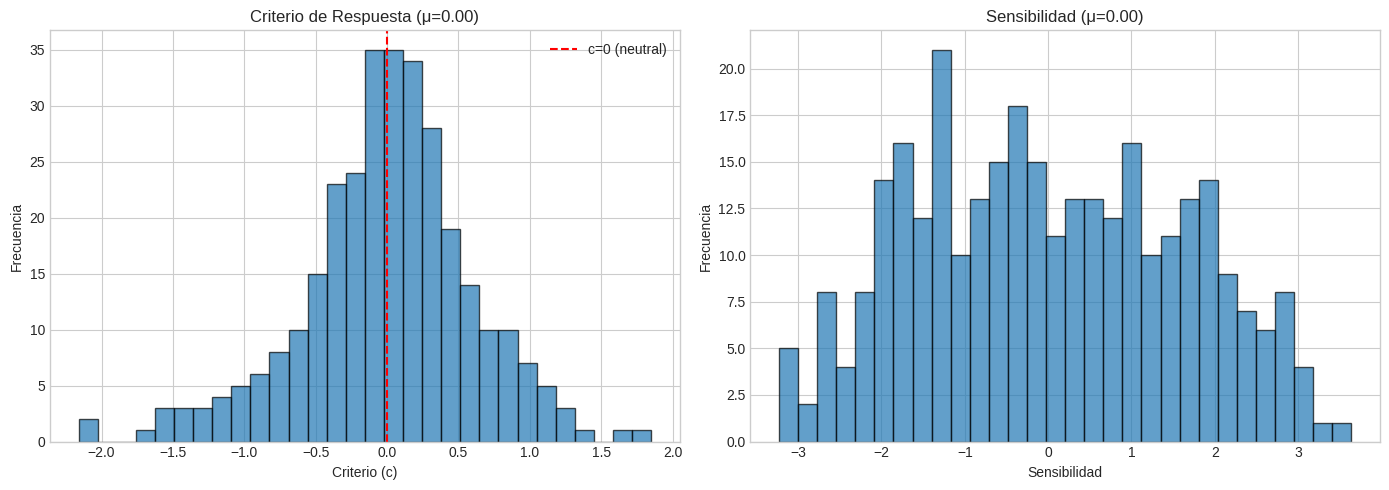

c > 0 (conservador): 164 sujetos
c < 0 (liberal): 146 sujetos


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Criterio c
ax1 = axes[0]
df['c'].dropna().hist(ax=ax1, bins=30, edgecolor='black', alpha=0.7)
ax1.axvline(0, color='red', linestyle='--', label='c=0 (neutral)')
ax1.set_xlabel('Criterio (c)')
ax1.set_ylabel('Frecuencia')
ax1.set_title(f'Criterio de Respuesta (μ={df["c"].mean():.2f})')
ax1.legend()

# Sensibilidad
ax2 = axes[1]
df['sensibilidad'].dropna().hist(ax=ax2, bins=30, edgecolor='black', alpha=0.7)
ax2.set_xlabel('Sensibilidad')
ax2.set_ylabel('Frecuencia')
ax2.set_title(f'Sensibilidad (μ={df["sensibilidad"].mean():.2f})')

plt.tight_layout()
plt.show()

print(f"c > 0 (conservador): {(df['c'] > 0).sum()} sujetos")
print(f"c < 0 (liberal): {(df['c'] < 0).sum()} sujetos")


## 5. Comparación por Origen


In [8]:
metrics = ['accuracy', 'HR', 'FA', 'c', 'sensibilidad', 'eficiencia']
comparison = df.groupby('origin')[metrics].agg(['mean', 'std', 'count'])
print("Comparación por origen:")
comparison.round(3)


Comparación por origen:


accuracy                  HR                  FA               \
                 mean    std count   mean    std count   mean    std count   
origin                                                                       
datapruebas     0.802  0.096    67  0.837  0.099    67  0.282  0.155    67   
neuropruebas    0.791  0.095   243  0.817  0.109   243  0.269  0.133   243   

                 c              sensibilidad              eficiencia         \
              mean    std count         mean    std count       mean    std   
origin                                                                        
datapruebas  -0.11  0.599    67        0.076  1.673    67      0.119  0.154   
neuropruebas  0.03  0.603   243       -0.021  1.575   243      0.087  0.148   

                    
             count  
origin              
datapruebas     67  
neuropruebas   243

## 6. Resumen Final


In [9]:
print("="*60)
print("RESUMEN GO/NO-GO ANALYSIS")
print("="*60)
print(f"\nTotal sujetos analizados: {len(df)}")
print(f"  - Datapruebas: {len(df[df['origin'] == 'datapruebas'])}")
print(f"  - Neuropruebas: {len(df[df['origin'] == 'neuropruebas'])}")

print(f"\nMétricas principales:")
print(f"  Accuracy: {df['accuracy'].mean():.2f} ± {df['accuracy'].std():.2f}")
print(f"  Hit Rate (HR): {df['HR'].mean():.2f} ± {df['HR'].std():.2f}")
print(f"  False Alarm (FA): {df['FA'].mean():.2f} ± {df['FA'].std():.2f}")
print(f"  Criterio (c): {df['c'].mean():.2f} ± {df['c'].std():.2f}")
print(f"  Sensibilidad: {df['sensibilidad'].mean():.2f} ± {df['sensibilidad'].std():.2f}")
print(f"  Media RT: {df['media_rt'].mean():.0f} ± {df['media_rt'].std():.0f} ms")


RESUMEN GO/NO-GO ANALYSIS

Total sujetos analizados: 310
  - Datapruebas: 67
  - Neuropruebas: 243

Métricas principales:
  Accuracy: 0.79 ± 0.10
  Hit Rate (HR): 0.82 ± 0.11
  False Alarm (FA): 0.27 ± 0.14
  Criterio (c): 0.00 ± 0.60
  Sensibilidad: 0.00 ± 1.59
  Media RT: 333 ± 26 ms


In [12]:
df

,subject_id,media_rt,mediana_rt,accuracy,FA,HR,eficiencia,recorded_at,user_agent,device,browser,platform,n_go_trials,n_nogo_trials,c,HR_FA_sin_estandarizar,sensibilidad,origin
0,b658934b-1bbc-4897-a989-1827a61cfb03,286.37,262.25,0.63,0.56,0.71,0.27,NaN,NaN,NaN,NaN,NaN,105,45,-0.53,-0.64,-3.13,datapruebas
1,f5a98897-4f58-4bc8-931e-4a2063542291,374.00,375.50,0.87,0.16,0.88,0.03,NaN,NaN,NaN,NaN,NaN,105,45,0.13,-0.52,1.36,datapruebas
2,4ba9507b-7579-4553-bc1c-d65cdb304613,329.86,328.90,0.70,0.40,0.74,0.14,NaN,NaN,NaN,NaN,NaN,105,45,-0.09,-0.57,-1.69,datapruebas
3,7d540a4e-9e01-472d-93aa-37f42cbfc693,332.04,331.90,0.93,0.09,0.94,0.03,NaN,NaN,NaN,NaN,NaN,105,45,0.11,-0.52,2.43,datapruebas
4,a31fee9a-3e68-4347-925c-cdc898edfc3f,351.02,362.00,0.68,0.62,0.81,0.43,NaN,NaN,NaN,NaN,NaN,105,45,-1.21,-0.72,-2.63,datapruebas
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305,a074d1e7-c9ac-440a-8397-7f68f6c94ffe,314.45,306.70,0.74,0.44,0.82,0.26,2022-05-07 01:06:55,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,WebKit,Chrome 101.0.4951.54,Windows 10.0,105,45,-0.60,-0.63,-1.23,neuropruebas
306,f519ef3b-73b9-4009-aef5-fb94de69b966,329.96,322.20,0.94,0.13,0.97,0.10,2022-10-04 18:18:52,Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/53...,WebKit,Chrome 105.0.0.0,Linux nan,105,45,-0.18,-0.55,2.42,neuropruebas
307,ba5e0b6e-55de-412c-a400-ca4381f8106e,313.98,305.85,0.86,0.29,0.92,0.21,2022-03-16 22:35:50,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,WebKit,Chrome 99.0.4844.51,Windows 10.0,105,45,-0.53,-0.60,0.79,neuropruebas
308,29cdc976-d5b7-4826-a20e-1a61ce707122,336.54,349.30,0.72,0.18,0.68,-0.15,2022-04-07 14:30:01,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,WebKit,Chrome 100.0.4896.75,Windows 10.0,105,45,0.99,-0.43,-0.65,neuropruebas


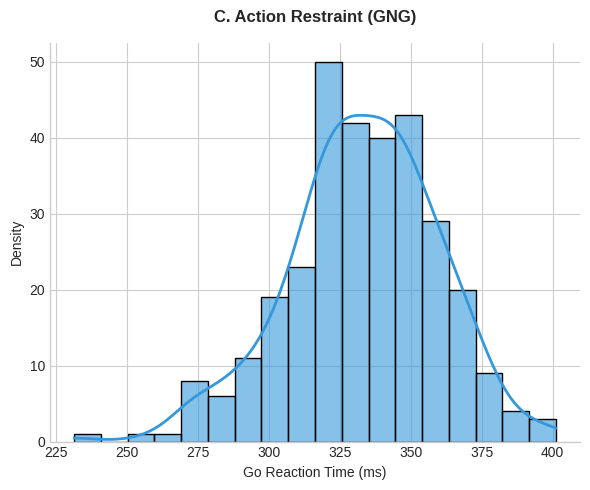

In [13]:
plt.figure(figsize=(6, 5))
sns.histplot(
    data=df, 
    x='media_rt', 
    kde=True, 
    color='#3498db', 
    line_kws={'linewidth': 2}, 
    alpha=0.6
)
plt.title('C. Action Restraint (GNG)', fontweight='bold', pad=15)
plt.ylabel('Density')
plt.xlabel('Go Reaction Time (ms)')
sns.despine()
plt.tight_layout()
# plt.savefig('Figure_2C_GNG.png', dpi=300)
plt.show()